<a href="https://colab.research.google.com/github/tdineth/Neural-Network---Deep-Learning-CO5420-4th-sem/blob/main/lab03/lab03_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Common imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


## Task 01: Implementing an MLP for the XOR Problem

In [2]:
from sklearn.neural_network import MLPClassifier

# Step 1: Define XOR data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])
print('XOR Inputs:', X_xor.tolist())
print('XOR Outputs:', y_xor.tolist())

XOR Inputs: [[0, 0], [0, 1], [1, 0], [1, 1]]
XOR Outputs: [0, 1, 1, 0]


In [3]:
# Step 2 & 3: Create and train MLP — 5 neurons, ReLU, 500 iters
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    max_iter=2000,
    random_state=4,
    solver='lbfgs'
)
mlp_xor.fit(X_xor, y_xor)
preds = mlp_xor.predict(X_xor)
print('Predictions:', preds.tolist())
print('Expected:   ', y_xor.tolist())
print(f'Accuracy: {(preds == y_xor).mean()*100:.1f}%')

Predictions: [0, 1, 1, 0]
Expected:    [0, 1, 1, 0]
Accuracy: 100.0%


In [4]:
# Q1: Weights and biases after training
print('=== Weights and Biases After Training ===')
for i, (w, b) in enumerate(zip(mlp_xor.coefs_, mlp_xor.intercepts_)):
    print(f'Layer {i+1} Weights:\n{w}')
    print(f'Layer {i+1} Biases: {b}\n')

=== Weights and Biases After Training ===
Layer 1 Weights:
[[ 1.33558349  3.31738208  1.53314314 -2.8204533   0.11877601]
 [-1.52191227  3.27865129 -1.64966126 -3.76460591 -0.03917083]]
Layer 1 Biases: [ 0.08728143 -3.23020514  0.02921016  3.79024661 -0.62244322]

Layer 2 Weights:
[[ 2.44908393]
 [-5.33149163]
 [ 1.72530107]
 [-4.93639672]
 [ 0.29629097]]
Layer 2 Biases: [9.26022844]



In [5]:
# Q3: Effect of increasing hidden layer to 10 neurons
mlp_10 = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                       max_iter=500, random_state=42, solver='lbfgs')
mlp_10.fit(X_xor, y_xor)
print('10-neuron hidden layer predictions:', mlp_10.predict(X_xor).tolist())
print(f'Accuracy: {(mlp_10.predict(X_xor)==y_xor).mean()*100:.1f}%')

10-neuron hidden layer predictions: [0, 1, 1, 0]
Accuracy: 100.0%


In [6]:
# Q4: Effect of tanh activation
mlp_tanh = MLPClassifier(hidden_layer_sizes=(5,), activation='tanh',
                         max_iter=500, random_state=42, solver='lbfgs')
mlp_tanh.fit(X_xor, y_xor)
print('tanh activation predictions:', mlp_tanh.predict(X_xor).tolist())
print(f'Accuracy: {(mlp_tanh.predict(X_xor)==y_xor).mean()*100:.1f}%')

tanh activation predictions: [0, 1, 1, 0]
Accuracy: 100.0%


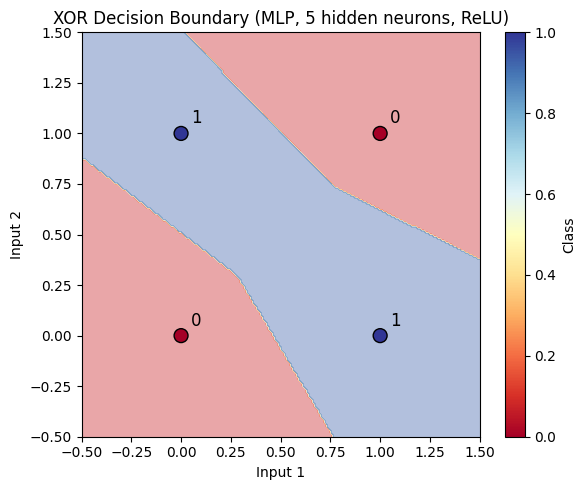

In [7]:
# Decision boundary visualization
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200), np.linspace(-0.5,1.5,200))
Z = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
scatter = plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor, s=100,
                      edgecolors='k', cmap='RdYlBu', zorder=3)
for i,(x,label) in enumerate(zip(X_xor, y_xor)):
    plt.text(x[0]+0.05, x[1]+0.05, str(label), fontsize=12)
plt.title('XOR Decision Boundary (MLP, 5 hidden neurons, ReLU)')
plt.xlabel('Input 1'); plt.ylabel('Input 2')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

## Task 02: Predicting California Housing Prices

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Step 1-2: Load and preprocess
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.10, random_state=42)

scaler = StandardScaler()
X_train_h_s = scaler.fit_transform(X_train_h)
X_test_h_s  = scaler.transform(X_test_h)

print(f'Training samples: {X_train_h_s.shape[0]}, Test samples: {X_test_h_s.shape[0]}')
print(f'Features: {X_train_h_s.shape[1]}')

Training samples: 18576, Test samples: 2064
Features: 8


In [9]:
# Step 3-4: Build and train MLPRegressor
mlp_housing = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    verbose=False
)
mlp_housing.fit(X_train_h_s, y_train_h)

y_pred_h = mlp_housing.predict(X_test_h_s)
mse = mean_squared_error(y_test_h, y_pred_h)
print(f'Test MSE (Adam, normalised): {mse:.4f}')
print(f'Test RMSE: {mse**0.5:.4f}')

Test MSE (Adam, normalised): 0.2987
Test RMSE: 0.5465


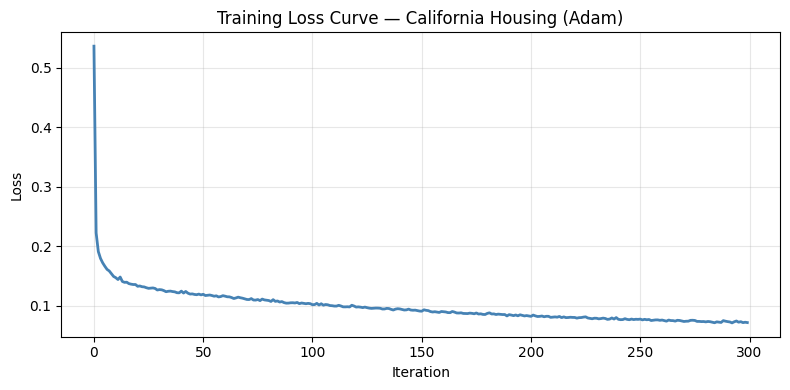

In [10]:
# Step 5: Loss curve
plt.figure(figsize=(8,4))
plt.plot(mlp_housing.loss_curve_, color='steelblue', lw=2)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Training Loss Curve — California Housing (Adam)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Q2: MSE without normalisation
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_h, y_h, test_size=0.10, random_state=42)
mlp_no_norm = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                           solver='adam', max_iter=300, random_state=42)
mlp_no_norm.fit(X_train_raw, y_train_raw)
mse_raw = mean_squared_error(y_test_raw, mlp_no_norm.predict(X_test_raw))
print(f'MSE without normalisation: {mse_raw:.4f}')
print(f'MSE with normalisation:    {mse:.4f}')
print(f'Improvement from normalisation: {((mse_raw-mse)/mse_raw)*100:.1f}%')

MSE without normalisation: 1.1610
MSE with normalisation:    0.2987
Improvement from normalisation: 74.3%


In [12]:
# Q3: SGD vs Adam
import time
mlp_sgd = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                       solver='sgd', max_iter=300, random_state=42)
t0 = time.time()
mlp_sgd.fit(X_train_h_s, y_train_h)
sgd_time = time.time() - t0
mse_sgd = mean_squared_error(y_test_h, mlp_sgd.predict(X_test_h_s))

t0 = time.time()
mlp_housing.fit(X_train_h_s, y_train_h)
adam_time = time.time() - t0

print(f'Adam — time: {adam_time:.2f}s, MSE: {mse:.4f}')
print(f'SGD  — time: {sgd_time:.2f}s, MSE: {mse_sgd:.4f}')

Adam — time: 101.96s, MSE: 0.2987
SGD  — time: 79.92s, MSE: 0.2871


In [13]:
# Q4: 70/30 split
X_tr70, X_te30, y_tr70, y_te30 = train_test_split(X_h, y_h, test_size=0.30, random_state=42)
X_tr70s = scaler.fit_transform(X_tr70); X_te30s = scaler.transform(X_te30)
mlp_70 = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                      solver='adam', max_iter=300, random_state=42)
mlp_70.fit(X_tr70s, y_tr70)
mse_70 = mean_squared_error(y_te30, mlp_70.predict(X_te30s))
print(f'MSE (90/10 split): {mse:.4f}')
print(f'MSE (70/30 split): {mse_70:.4f}')

MSE (90/10 split): 0.2987
MSE (70/30 split): 0.2834


In [14]:
# Q5: Deeper architecture (256,128,64,32)
mlp_deep = MLPRegressor(hidden_layer_sizes=(256,128,64,32), activation='relu',
                        solver='adam', max_iter=300, random_state=42)
mlp_deep.fit(X_train_h_s, y_train_h)
mse_deep = mean_squared_error(y_test_h, mlp_deep.predict(X_test_h_s))
print(f'MSE (128,64,32):    {mse:.4f}')
print(f'MSE (256,128,64,32): {mse_deep:.4f}')

MSE (128,64,32):    0.2987
MSE (256,128,64,32): 0.2890


## Task 03: Image Classification with MLP (MNIST 0 vs 1)

In [15]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load MNIST (subset: digits 0 and 1)
print('Loading MNIST...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_m, y_m = mnist.data, mnist.target.astype(int)

mask = (y_m == 0) | (y_m == 1)
X_m, y_m = X_m[mask], y_m[mask]
print(f'Subset size: {X_m.shape[0]} samples (digits 0 and 1)')

Loading MNIST...
Subset size: 14780 samples (digits 0 and 1)


Train: 11824, Test: 2956


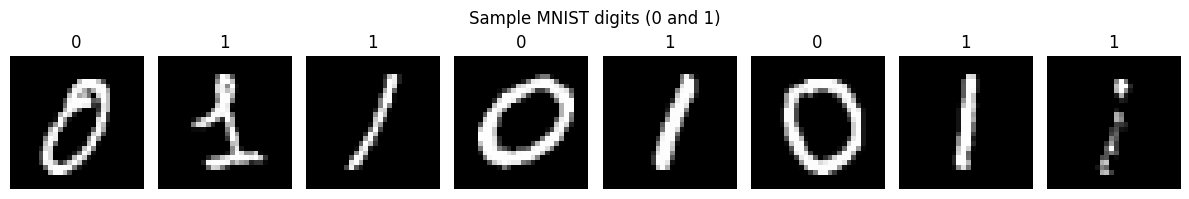

In [16]:
# Preprocess: normalize and split 80/20
X_m = X_m / 255.0
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.20, random_state=42, stratify=y_m)
print(f'Train: {X_train_m.shape[0]}, Test: {X_test_m.shape[0]}')

# Show sample images
fig, axes = plt.subplots(1, 8, figsize=(12,2))
for ax, img, lbl in zip(axes, X_train_m[:8], y_train_m[:8]):
    ax.imshow(img.reshape(28,28), cmap='gray')
    ax.set_title(str(lbl)); ax.axis('off')
plt.suptitle('Sample MNIST digits (0 and 1)')
plt.tight_layout()
plt.show()

In [17]:
# Build and train MLPClassifier
mlp_mnist = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=50,
    random_state=42,
    verbose=False
)
mlp_mnist.fit(X_train_m, y_train_m)
y_pred_m = mlp_mnist.predict(X_test_m)
acc = (y_pred_m == y_test_m).mean()
print(f'Test Accuracy: {acc*100:.2f}%')

Test Accuracy: 99.93%


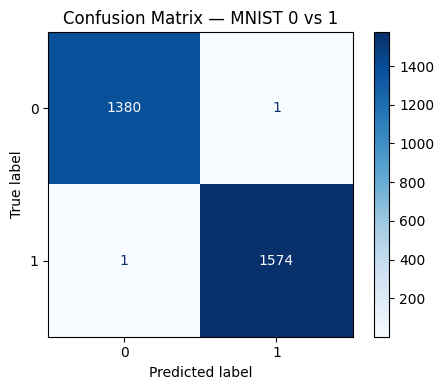


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1381
           1       1.00      1.00      1.00      1575

    accuracy                           1.00      2956
   macro avg       1.00      1.00      1.00      2956
weighted avg       1.00      1.00      1.00      2956



In [19]:
# Confusion matrix
cm = confusion_matrix(y_test_m, y_pred_m)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — MNIST 0 vs 1')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test_m, y_pred_m, target_names=['0','1']))

Misclassified samples: 2


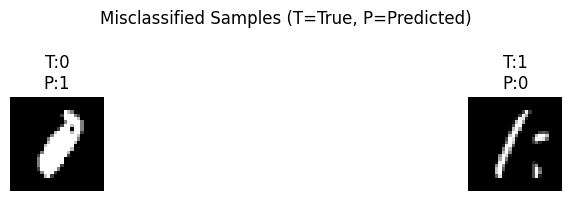

In [20]:
# Q3: Misclassified samples
wrong_idx = np.where(y_pred_m != y_test_m)[0]
print(f'Misclassified samples: {len(wrong_idx)}')
if len(wrong_idx) > 0:
    n_show = min(8, len(wrong_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(12,2))
    if n_show == 1: axes = [axes]
    for ax, idx in zip(axes, wrong_idx[:n_show]):
        ax.imshow(X_test_m[idx].reshape(28,28), cmap='gray')
        ax.set_title(f'T:{y_test_m[idx]}\nP:{y_pred_m[idx]}')
        ax.axis('off')
    plt.suptitle('Misclassified Samples (T=True, P=Predicted)')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples!')

In [21]:
# Q4: Effect of 90% train split
X_tr90, X_te10, y_tr90, y_te10 = train_test_split(
    X_m, y_m, test_size=0.10, random_state=42, stratify=y_m)
mlp_90 = MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                       solver='sgd', learning_rate_init=0.01, max_iter=50, random_state=42)
mlp_90.fit(X_tr90, y_tr90)
acc_90 = (mlp_90.predict(X_te10) == y_te10).mean()
print(f'Accuracy with 80% train: {acc*100:.2f}%')
print(f'Accuracy with 90% train: {acc_90*100:.2f}%')

Accuracy with 80% train: 99.93%
Accuracy with 90% train: 99.86%


## Task 04: Hyperparameter Tuning with GridSearchCV

In [22]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Use California Housing from Task 02 (already split and scaled)
param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd']
}

grid_search = GridSearchCV(
    MLPRegressor(max_iter=300, random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV (this may take a few minutes)...')
grid_search.fit(X_train_h_s, y_train_h)
print('Done!')

Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done!


In [23]:
# Display results
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_hidden_layer_sizes','param_activation','param_solver',
        'mean_test_score','std_test_score','rank_test_score']
results_df['MSE'] = -results_df['mean_test_score']
display_df = results_df[['param_hidden_layer_sizes','param_activation','param_solver','MSE','rank_test_score']]
display_df = display_df.sort_values('rank_test_score').reset_index(drop=True)
print(display_df.to_string())

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV MSE:     {-grid_search.best_score_:.4f}')

  param_hidden_layer_sizes param_activation param_solver       MSE  rank_test_score
0                (128, 64)             tanh         adam  0.265424                1
1                (128, 64)             relu         adam  0.267708                2
2           (256, 128, 64)             relu          sgd  0.280228                3
3           (256, 128, 64)             relu         adam  0.296247                4
4                (128, 64)             relu          sgd  0.298259                5
5           (256, 128, 64)             tanh          sgd  0.307852                6
6           (256, 128, 64)             tanh         adam  0.308809                7
7                (128, 64)             tanh          sgd  0.333119                8

Best parameters: {'activation': 'tanh', 'hidden_layer_sizes': (128, 64), 'solver': 'adam'}
Best CV MSE:     0.2654


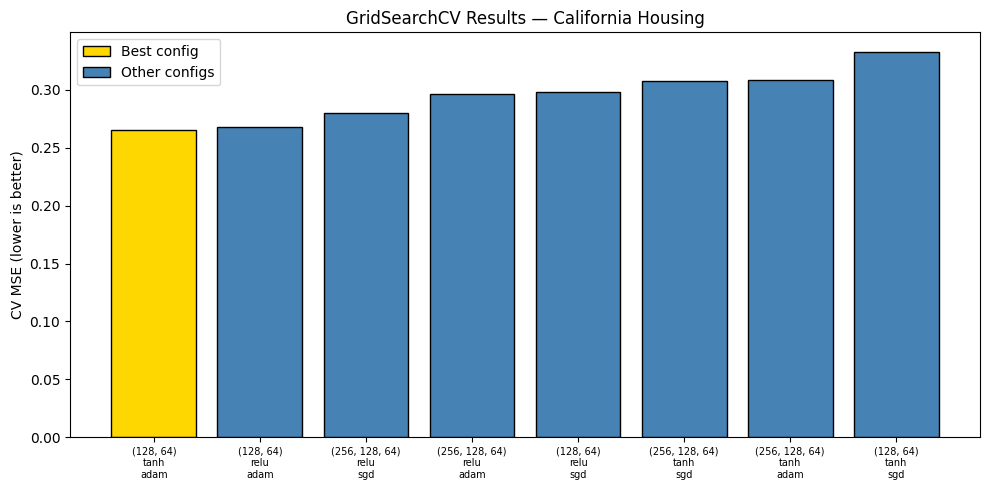

In [25]:
# Visualise grid search results
fig, ax = plt.subplots(figsize=(10, 5))
configs = [f"{r['param_hidden_layer_sizes']}\n{r['param_activation']}\n{r['param_solver']}"
           for _, r in display_df.iterrows()]
mses = display_df['MSE'].values
colors = ['gold' if i==0 else 'steelblue' for i in range(len(mses))]
bars = ax.bar(range(len(configs)), mses, color=colors, edgecolor='black')
ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs, fontsize=7)
ax.set_ylabel('CV MSE (lower is better)')
ax.set_title('GridSearchCV Results — California Housing')
ax.legend([bars[0], bars[1]], ['Best config', 'Other configs'])
plt.tight_layout()
plt.show()

In [26]:
# Q3: What if activation set to 'logistic'?
param_grid_log = {
    'hidden_layer_sizes': [(128,64),(256,128,64)],
    'activation': ['logistic'],
    'solver': ['adam','sgd']
}
gs_log = GridSearchCV(MLPRegressor(max_iter=300,random_state=42), param_grid_log,
                      cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_log.fit(X_train_h_s, y_train_h)
print(f'Best logistic config: {gs_log.best_params_}')
print(f'Best logistic CV MSE: {-gs_log.best_score_:.4f}')
print(f'Best relu/tanh CV MSE: {-grid_search.best_score_:.4f}')

Best logistic config: {'activation': 'logistic', 'hidden_layer_sizes': (256, 128, 64), 'solver': 'adam'}
Best logistic CV MSE: 0.2756
Best relu/tanh CV MSE: 0.2654


In [27]:
# Q5: 3-fold vs 5-fold CV
best_p = grid_search.best_params_
gs_3 = GridSearchCV(MLPRegressor(max_iter=300,random_state=42),
                    {k:[v] for k,v in best_p.items()},
                    cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gs_3.fit(X_train_h_s, y_train_h)

gs_5 = GridSearchCV(MLPRegressor(max_iter=300,random_state=42),
                    {k:[v] for k,v in best_p.items()},
                    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_5.fit(X_train_h_s, y_train_h)

print(f'3-fold CV MSE: {-gs_3.best_score_:.4f} (std: {gs_3.cv_results_["std_test_score"][0]:.4f})')
print(f'5-fold CV MSE: {-gs_5.best_score_:.4f} (std: {gs_5.cv_results_["std_test_score"][0]:.4f})')

3-fold CV MSE: 0.2714 (std: 0.0013)
5-fold CV MSE: 0.2654 (std: 0.0123)
